# 02 - Image Pipeline Test\n
\n
Prueba transformaciones de `MammographyImage` y su historial.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'api_stable').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from api_stable.mammography import MammographyDicom

DICOM_PATH = Path('/home/eloygarcia/Escritorio/Datasets/Mammo-MX/B1/000077_R_MLO_B1_D2')
if not DICOM_PATH.exists():
    raise FileNotFoundError(f'Actualiza DICOM_PATH: {DICOM_PATH}')

mammo = MammographyDicom.from_dicom(DICOM_PATH)
mammo.ensure_monochrome2()
img = mammo.image.copy()

AttributeError: 'MammographyDicom' object has no attribute 'ensure_monochrome2'

In [ ]:
original = img.to_numpy().copy()
#mamo.convert_to_monochrome2()
#img.ensure_monochrome2()

# apply_windowing depende de atributos DICOM en la instancia\n
if hasattr(mammo.ds, 'WindowCenter') and hasattr(mammo.ds, 'WindowWidth'):
    mammo.apply_windowing()

#mammo.normalize()
processed = mammo.image.to_numpy().copy()

print('history:', mammo.image.get_history())
print('processed min/max:', processed.min(), processed.max())

In [3]:
print(mammo.metadata)


MammographyMetadata(patient=PatientInfo(patient_id='', age=44, sex=''), vendor=VendorInfo(manufacturer='HOLOGIC, Inc.', model_name='Selenia Dimensions'), acquisition=AcquisitionInfo(kvp='30', exposure='66', exposure_time='560', tube_current='100', compression_force='89.40883'), breast=BreastInfo(laterality='R', view='MLO', breast_implant_present=False), image=ImageInfo(rows=4096, columns=3328, bits_stored=12, pixel_spacing=(0.065238, 0.065238), photometric_interpretation='MONOCHROME2', presentation_lut_shape='IDENTITY', window_center='2047', window_width='4096', window_center_width_explanation=None, voi_lut_function=None))


In [4]:
original = mammo.image.to_numpy().copy()

mammo.initialize_image()

#mammo.normalize()
processed = mammo.image.to_numpy().copy()

print('history:', mammo.image.get_history())
print('processed min/max:', processed.min(), processed.max())

history: ['apply_windowing( window_center=2047, window_width=4096.0, voi_lut_function=LINEAR)']
processed min/max: 0.0 4092.0004884004884


In [5]:
import numpy as np

print(original)
print(np.min(original))
print(np.max(original))

print(processed)
print(np.min(processed))
print(np.max(processed))

print(np.abs(processed-original))
print(np.min(np.abs(processed-original)))
print(np.max(np.abs(processed-original)))

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
0
4093
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
0.0
4092.0004884004884
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
0.0
0.9995115995116066


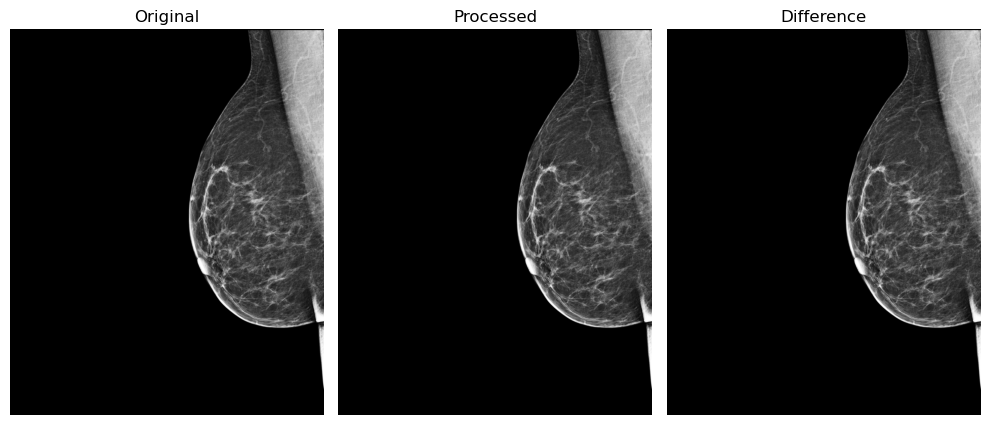

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(original, vmin=mammo.image.min, vmax=mammo.image.max, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(processed, vmin=mammo.image.min, vmax=mammo.image.max, cmap='gray')
ax[1].set_title('Processed')
ax[1].axis('off')
plt.tight_layout()

ax[2].imshow(np.abs(processed-original), cmap='gray')
ax[2].set_title('Difference')
ax[2].axis('off')
plt.tight_layout()